In [3]:
import numpy as np
import socket
import cv2
import matplotlib.pyplot as plt

## Run the Java Tetris Server using subprocess

In [21]:
import subprocess
subprocess.Popen(["/usr/bin/java","-jar","/home/rvl/mingwei/NTUT_Deep_Learning/hw4/TetrisTCPserver_v0.6.jar"])

<Popen: returncode: None args: ['/usr/bin/java', '-jar', '/home/rvl/mingwei/...>

Tetris TCP server is listening at 10612


## Create our own Tetris Test environment by inheriting Gym class

In [22]:
import gymnasium as gym
from gymnasium import spaces

In [ ]:
class TetrisEnv(gym.Env):

    metadata = {"render_modes": ["human"], "render_fps": 20}

    '''
        The supported actions are
        0: move -1
        1: move 1
        2: rotate 0 // counter-clockwise
        3: rotate 1 // clockwise
        4: drop down
    '''
    N_DISCRETE_ACTIONS = 5

    IMG_HEIGHT = 200
    IMG_WIDTH = 100
    IMG_CHANNELS = 3


    def __init__(self, host_ip="127.0.0.1", host_port=10612):
        super().__init__()

        self.action_space = spaces.Discrete(self.N_DISCRETE_ACTIONS)
        # Example for using image as input (channel-first; channel-last also works):
        self.observation_space = spaces.Box(low=0, high=255,
                                            shape=(self.IMG_HEIGHT, self.IMG_WIDTH, self.IMG_CHANNELS), dtype=np.uint8)
        self.server_ip = host_ip
        self.server_port = host_port

        self.client_sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        self.client_sock.connect((self.server_ip, self.server_port))

    def step(self, action):
        if action == 0:
            self.client_sock.sendall(b"move -1\n")
        elif action == 1:
            self.client_sock.sendall(b"move 1\n")
        elif action == 2:
            self.client_sock.sendall(b"rotate 0\n")
        elif action == 3:
            self.client_sock.sendall(b"rotate 1\n")
        elif action == 4:
            self.client_sock.sendall(b"drop\n")

        terminated, lines, height, holes, observation = self.get_tetris_server_response(self.client_sock)
        self.observation = observation

        # reward = 0
        # if action == 4: # Drop reward
        #     reward += 5

        # # Negative height reward
        # if height > self.height:
        #     reward -= (height - self.height)*5

        # # Positive hole reduction reward
        # if holes < self.holes:
        #     reward += (self.holes - holes)*10

        # if lines > self.lines_removed:
        #     reward = reward + (lines - self.lines_removed)*1000
        #     self.lines_removed = lines
        reward = 0
        if action == 4:  # Drop reward
            reward += 3  # 降低下落獎勵，更注重消除行

        # Negative height reward
        if height > self.height:
            reward -= (height - self.height)*3  # 降低高度懲罰

        # Positive hole reduction reward
        if holes < self.holes:
            reward += (self.holes - holes)*15  # 增加減少洞的獎勵

        # 消除行獎勵
        if lines > self.lines_removed:
            lines_cleared = lines - self.lines_removed
            # 根據一次消除的行數給予不同獎勵
            if lines_cleared == 1:
                reward += 1000
            elif lines_cleared == 2:
                reward += 3000
            elif lines_cleared == 3:
                reward += 5000
            elif lines_cleared == 4:
                reward += 8000
            self.lines_removed = lines

        self.holes = holes
        self.height = height
        self.lifetime += 1
        truncated = False
        info = {'removed_lines':self.lines_removed, 'lifetime':self.lifetime}
        return (observation, reward, terminated, truncated, info)

    def reset(self, seed=None, options=None):
        self.client_sock.sendall(b"start\n")
        terminated, lines, height, holes, observation = self.get_tetris_server_response(self.client_sock)

        if observation is None:
            observation = np.zeros((self.IMG_HEIGHT, self.IMG_WIDTH, self.IMG_CHANNELS), dtype=np.uint8)
            
        self.observation = observation
        self.reward = 0
        self.lines_removed = 0
        self.holes = 0
        self.height = 0
        self.lifetime = 0
        info = {}
        return observation, info

    def render(self):
        ''''''
        #if self.render_mode == "console":
        #    print('Total reward ' + str(self.reward))
        '''
        if self.render_mode == "human":
            cv2.imshow("Image", self.observation)
            cv2.waitKey(0)
            cv2.destroyAllWindows()
        '''

    def close(self):
        self.client_sock.close()

    def get_tetris_server_response(self, sock):
        is_game_over = (sock.recv(1) == b'\x01')
        removed_lines = int.from_bytes(sock.recv(4), 'big')
        height = int.from_bytes(sock.recv(4), 'big')
        holes = int.from_bytes(sock.recv(4), 'big')
        img_size = int.from_bytes(sock.recv(4), 'big')
        img_png = sock.recv(img_size)
        
        nparr = np.frombuffer(img_png, np.uint8)
        np_image = cv2.imdecode(nparr, -1)

        if np_image is None:
            np_image = np.zeros((self.IMG_HEIGHT, self.IMG_WIDTH, self.IMG_CHANNELS), dtype=np.uint8)

        return is_game_over, removed_lines, height, holes, np_image

## Use SB3 env_checker to check our environment

In [24]:
from stable_baselines3.common.env_checker import check_env

env = TetrisEnv()
# It will check your custom environment and output additional warnings if needed
# No response may be caused by mismatched action state definition and implementation
check_env(env)

Client has joined the game


## Randomly test the environment

In [25]:
obs, info = env.reset()
n_steps = 20
for _ in range(n_steps):
    # Random action
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    
    env.render() # We render nothing now
    
    if terminated:
        break

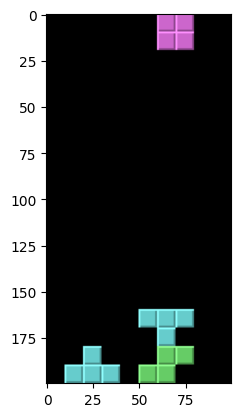

In [26]:
# Show the final screen
%matplotlib inline 
plt.imshow(obs)

## Create an environment with 30 client threads

In [33]:
from stable_baselines3 import PPO, A2C, DQN, DDPG
from stable_baselines3.common.env_util import make_vec_env

In [30]:
# Let's try A2C by creating 30 environments
vec_env = make_vec_env(TetrisEnv, n_envs=30)

Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
C

## We choose A2C with CNN policy, and train 1,000,000 steps

In [ ]:
import torch

if torch.cuda.is_available():
    print(f"使用GPU: {torch.cuda.get_device_name(0)}")
    device = "cuda"
else:
    print("沒有可用的GPU，將使用CPU")
    device = "cpu"

# Train the agent
model = DDPG("CnnPolicy", 
            vec_env, 
            verbose=1, 
            device=device, 
            tensorboard_log="./sb3_log/").learn(1000000)

Using cuda device
Wrapping the env in a VecTransposeImage.
Logging to ./sb3_log/A2C_2
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 94.5     |
|    ep_rew_mean        | -95.8    |
| time/                 |          |
|    fps                | 407      |
|    iterations         | 100      |
|    time_elapsed       | 36       |
|    total_timesteps    | 15000    |
| train/                |          |
|    entropy_loss       | -0.0105  |
|    explained_variance | 0.765    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -0.00107 |
|    value_loss         | 14.3     |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 91.3     |
|    ep_rew_mean        | -94      |
| time/                 |          |
|    fps                | 402      |
|    iterations         | 200      |
|    time_elapsed       | 

## Visualize Traing Process via Tensorboard

In [ ]:
# %load_ext tensorboard
# %tensorboard --logdir /content/sb3_log/A2C_1/

## Test our model with 1000 steps and record all plays.

In [32]:
import os
import shutil

# Test the trained agent
# using the vecenv
obs = vec_env.reset()
test_steps = 1000

replay_folder = './replay'
if os.path.exists(replay_folder):
    shutil.rmtree(replay_folder)

n_env = obs.shape[0] # Number of environments. A2C will play all envs
ep_id = np.zeros(n_env, int)
ep_steps = np.zeros(n_env, int)
cum_reward = np.zeros(n_env)
max_reward = -1e10
max_game_id = 0
max_ep_id = 0
max_rm_lines = 0
max_lifetime = 0

for step in range(test_steps):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = vec_env.step(action)

    if step % 50 == 0:
        print(f"Step {step}")
        print("Action: ", action)
        print("reward=", reward, " done=", done)

    for eID in range(n_env):
        cum_reward[eID] += reward[eID]
        folder = f'{replay_folder}/{eID}/{ep_id[eID]}'
        if not os.path.exists(folder):
            os.makedirs(folder)
        fname = folder + '/' + '{:06d}'.format(ep_steps[eID]) + '.png'
        cv2.imwrite(fname, obs[eID])
        #cv2.imshow("Image" + str(eID), obs[eID])
        #cv2.waitKey(10)
        ep_steps[eID] += 1

        if done[eID]:
            if cum_reward[eID] > max_reward:
                max_reward = cum_reward[eID]
                max_game_id = eID
                max_ep_id = ep_id[eID]
                max_rm_lines = info[eID]['removed_lines']
                max_lifetime = info[eID]['lifetime']

            ep_id[eID] += 1
            cum_reward[eID] = 0
            ep_steps[eID] = 0


Step 0
Action:  [3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]
reward= [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]  done= [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False]
Step 50
Action:  [4 0 0 0 0 0 3 0 0 4 0 0 0 0 0 4 0 0 3 0 0 4 0 0 0 0 0 3 0 0]
reward= [ 5.  0.  0.  0.  0.  0.  0.  0.  0.  5.  0.  0.  0.  0.  0. -5.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]  done= [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False]
Step 100
Action:  [0 4 4 3 3 1 4 0 0 4 0 4 0 0 1 4 1 0 0 4 0 0 1 4 0 1 4 0 0 4]
reward= [ 0. -5.  0.  0.  0.  0.  5.  0.  0.  5.  0. -5.  0.  0.  0.  0.  0.  0.
  0. -5.  0.  0.  0.  5.  0.  0.  0.  0.  0.  0.]  done= [False Fals

In [35]:
best_replay_path = f'{replay_folder}/{max_game_id}/{max_ep_id}'


print("After playing 30 envs each for ", test_steps, " steps:")
print(" Max reward=", max_reward, " Best video: " + best_replay_path)
print(" Removed lines=", max_rm_lines, " lifetime=", max_lifetime)

After playing 30 envs each for  1000  steps:
 Max reward= 3130.0  Best video: ./replay/3/7
 Removed lines= 3  lifetime= 151


## Write "removed lines" and "played steps" into a CSV file and create download link

In [36]:
with open('tetris_best_score.csv', 'w') as fs:
    fs.write('id,removed_lines,played_steps\n')
    fs.write(f'0,{max_rm_lines}, {max_lifetime}\n')
    fs.write(f'1,{max_rm_lines}, {max_lifetime}\n')

## Make a gif image to visualize the best play

In [39]:
import glob
import imageio

filenames = sorted(glob.glob(best_replay_path + '/*.png'))

images = []
for filename in filenames:
    images.append(imageio.imread(filename))
imageio.mimsave('replay.gif', images, loop=0)

/tmp/ipykernel_15244/3508690983.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread(filename))


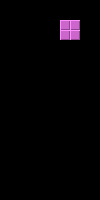

Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Connection reset
Client has joined the game
Client has exited the game
Client has joined the game
Client has 

In [ ]:
from IPython.display import Image
Image(filename='/home/rvl/mingwei/NTUT_Deep_Learning/hw4/replay.gif')

## Save your model "your_studentID_a2c_30env.zip"

In [20]:
model.save('your_studentID_a2c_30env_1M.zip')